# Notebook 14: Mean Reversion of the Kalman Spread

## Objective

The Kalman filter constructed a **dynamic equilibrium relationship** between USD and EUR 5Y yields.

The resulting spread

$$
S_t = y_t - \alpha_t - \beta_t x_t
$$

represents the **residual relative value dislocation** between the two markets.

The key question now is:

**Does this spread exhibit mean reversion?**

Relative value strategies rely on spreads reverting toward equilibrium.  
To test this formally, we model the spread using an **Ornstein–Uhlenbeck (OU) process**.

## Ornstein–Uhlenbeck Model

The spread is modeled as

$$
dS_t = \kappa (\mu - S_t) dt + \sigma dW_t
$$

where

- $S_t$ = spread
- $\mu$ = long-run equilibrium
- $\kappa$ = speed of mean reversion
- $\sigma$ = diffusion volatility
- $W_t$ = Brownian motion

If $\kappa > 0$, the spread is mean reverting.

---

### Discrete Estimation

In discrete time we estimate

$$
\Delta S_t = a + b S_{t-1} + \varepsilon_t
$$

Mapping to OU parameters:

$$
\kappa = -b
$$

$$
\mu = -\frac{a}{b}
$$

The **half-life of mean reversion** is

$$
t_{1/2} = \frac{\ln(2)}{\kappa}
$$

The half-life measures how quickly the spread returns to equilibrium.

In [10]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
def find_repo_root(start=None):
    if start is None:
        start = Path.cwd().resolve()

    for path in [start] + list(start.parents):
        if (path / "src").exists():
            return path

    raise FileNotFoundError("Could not locate repo root.")

ROOT = find_repo_root()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Repo root:", ROOT)

Repo root: C:\Users\kiefe\OneDrive\Documents\GitHub\Cross-Country-Rates-Relative-Value-NUSInvest2526


In [12]:
# PAIR_ID = "USD_EUR_5Y"
PAIR_ID = "JPY-AUD 5Y"

spread_path = ROOT / "results" / "spreads" / f"{PAIR_ID}_kalman.parquet"

print("Loading:", spread_path)

spread_df = pd.read_parquet(spread_path)

spread_df.head()

Loading: C:\Users\kiefe\OneDrive\Documents\GitHub\Cross-Country-Rates-Relative-Value-NUSInvest2526\results\spreads\JPY-AUD 5Y_kalman.parquet


,y,x,alpha_t,beta_t,spread_t,innovation_t,innovation_var_t,innovation_z_t,pair_id
date,,,,,,,,,
1999-11-02,0.887,6.275,0.000000,1.000000,-5.388000,0.000000,0.000000,NaN,JPY-AUD 5Y
1999-12-06,0.979,6.323,-0.130087,0.177462,-0.013009,-5.344000,41.080370,-0.833776,JPY-AUD 5Y
1999-12-07,0.997,6.285,-0.129597,0.178312,0.005907,0.011735,0.198666,0.026328,JPY-AUD 5Y
1999-12-08,0.968,6.298,-0.129964,0.177027,-0.016952,-0.025411,0.149897,-0.065634,JPY-AUD 5Y
1999-12-09,0.948,6.295,-0.130485,0.175665,-0.027323,-0.036421,0.133298,-0.099757,JPY-AUD 5Y


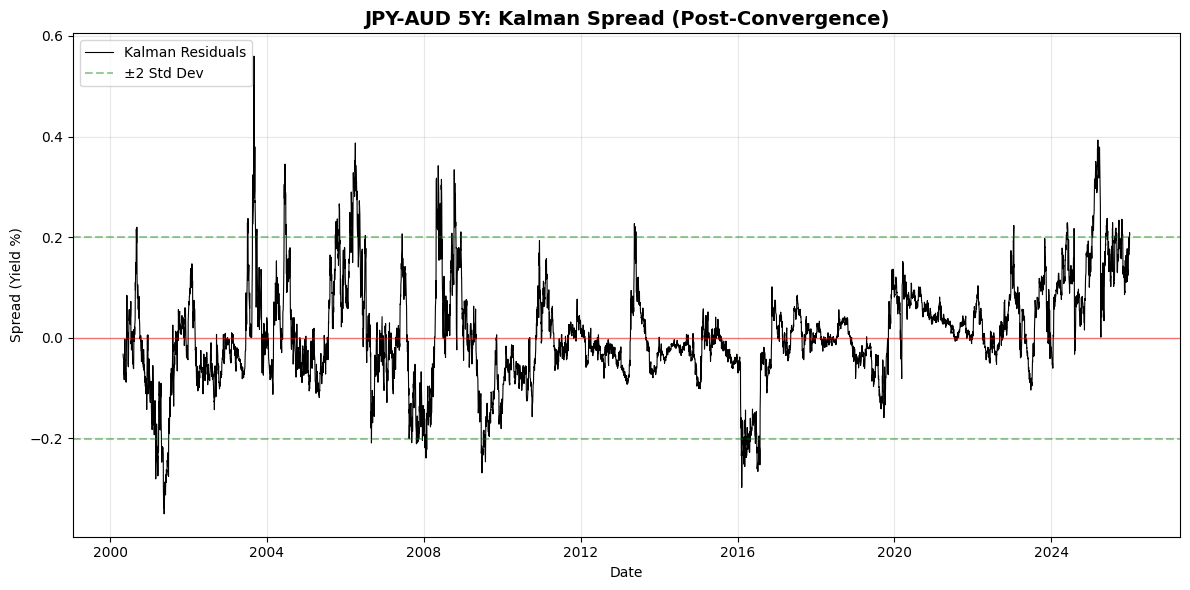

Spread Standard Deviation: 0.1004


In [13]:
"""
plt.figure(figsize=(12,5))
plt.plot(spread_df.index, spread_df["spread_t"])
plt.title("Kalman Spread")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.grid(alpha=0.3)
plt.show()
"""

# --- 1. Define Burn-in Period ---
# We skip the first 100 trading days to let the Kalman Filter converge
BURN_IN = 100 
plot_df = spread_df.iloc[BURN_IN:]

# --- 2. Improved Plotting ---
plt.figure(figsize=(12, 6))

# Plot the Spread
plt.plot(plot_df.index, plot_df["spread_t"], color='black', linewidth=0.8, label="Kalman Residuals")

# Add a zero line
plt.axhline(y=0, color='red', linestyle='-', linewidth=1, alpha=0.5)

# Add Standard Deviation Bands for context (helps identify "cheap/expensive" levels)
std_spread = plot_df["spread_t"].std()
plt.axhline(y=std_spread * 2, color='green', linestyle='--', alpha=0.4, label='±2 Std Dev')
plt.axhline(y=-std_spread * 2, color='green', linestyle='--', alpha=0.4)

# Formatting
plt.title(f"{PAIR_ID}: Kalman Spread (Post-Convergence)", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Spread (Yield %)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Spread Standard Deviation: {std_spread:.4f}")

In [14]:
spread = plot_df["spread_t"].dropna() 

delta = spread.diff()
lag = spread.shift(1)

df = pd.concat([delta, lag], axis=1)
df.columns = ["dS", "S_lag"]
df = df.dropna()

df.head()

,dS,S_lag
date,,
2000-05-02,-0.005116,-0.032935
2000-05-08,-0.007679,-0.038051
2000-05-09,-0.027733,-0.045730
2000-05-10,0.005841,-0.073463
2000-05-11,-0.015813,-0.067621


In [15]:
import statsmodels.api as sm

X = sm.add_constant(df["S_lag"])
model = sm.OLS(df["dS"], X).fit()

a = model.params["const"]
b = model.params["S_lag"]

kappa = -b
mu = -a / b if b != 0 else np.nan

half_life = np.log(2) / kappa if kappa > 0 else np.inf

print("Mean reversion speed (kappa):", kappa)
print("Long run mean (mu):", mu)
print("Half-life (days):", half_life)
print(model.summary())

Mean reversion speed (kappa): 0.01850741279011925
Long run mean (mu): 0.006781351174006348
Half-life (days): 37.45240830906431
                            OLS Regression Results                            
Dep. Variable:                     dS   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     60.63
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           7.96e-15
Time:                        00:33:09   Log-Likelihood:                 16653.
No. Observations:                6595   AIC:                        -3.330e+04
Df Residuals:                    6593   BIC:                        -3.329e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----

## Explanation

The OU estimation tests whether the Kalman spread exhibits **statistically significant mean reversion**.

Key quantities:

- **Mean reversion speed ($\kappa$)**  
  Measures how quickly the spread returns to equilibrium.

- **Long-run mean ($\mu$)**  
  Represents the equilibrium level of the spread.

- **Half-life ($t_{1/2}$)**  
  Measures the expected time required for half of a spread deviation to revert.

### Economic Interpretation

If the spread has:

- **positive $\kappa$**
- **finite half-life**

then the spread behaves as a **mean-reverting process**, supporting the relative value hypothesis.

This means deviations from equilibrium are likely to **correct over time**, making the spread potentially tradable.

If $\kappa$ is close to zero or negative, the spread behaves more like a **random walk**, indicating that relative value relationships may be unstable in that regime.

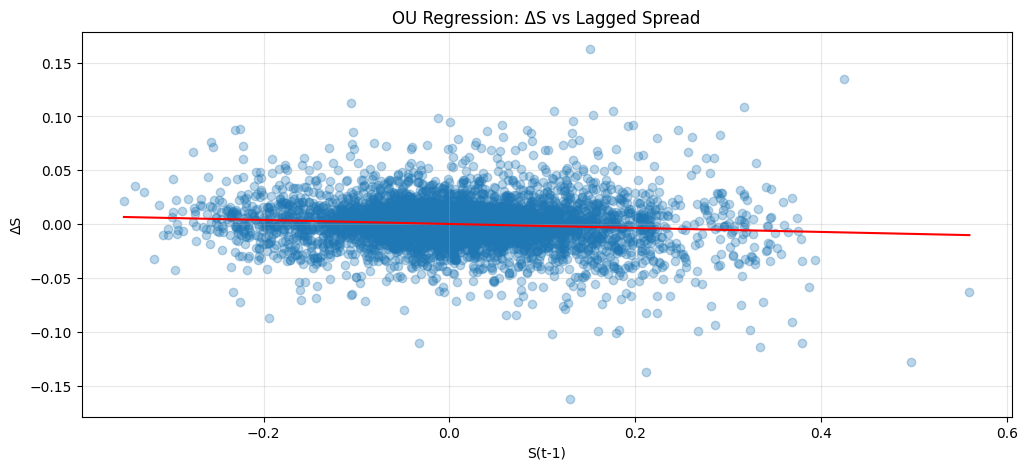

In [17]:
plt.figure(figsize=(12,5))
plt.scatter(df["S_lag"], df["dS"], alpha=0.3)

x = np.linspace(df["S_lag"].min(), df["S_lag"].max(), 100)
y = a + b*x

plt.plot(x, y, color="red")
plt.title("OU Regression: ΔS vs Lagged Spread")
plt.xlabel("S(t-1)")
plt.ylabel("ΔS")
plt.grid(alpha=0.3)
plt.show()

In [16]:
# --- ADD THIS TO THE BOTTOM OF NOTEBOOK 14 ---
import os

# Create the results/ou directory if it doesn't exist
ou_dir = ROOT / "results" / "ou"
ou_dir.mkdir(parents=True, exist_ok=True)

# Prepare the data for export (using your JPY-AUD results)
ou_results = pd.DataFrame([{
    "pair_id": PAIR_ID,
    "regime": 0, # Since we validated JPY-AUD in Regime 0
    "mu": mu,
    "kappa": kappa,
    "sigma": model.resid.std() * np.sqrt(252), # Annualized vol for OU
    "half_life": half_life
}])

# Save as the CSV Notebook 15 expects
ou_output_path = ou_dir / f"{PAIR_ID}_ou_params.csv"
ou_results.to_csv(ou_output_path, index=False)

print(f"SUCCESS: Saved OU parameters to {ou_output_path}")

SUCCESS: Saved OU parameters to C:\Users\kiefe\OneDrive\Documents\GitHub\Cross-Country-Rates-Relative-Value-NUSInvest2526\results\ou\JPY-AUD 5Y_ou_params.csv


## Role in the Trading Framework

The OU model confirms whether the Kalman spread behaves like a **mean-reverting process**.

If the spread mean-reverts with a reasonable half-life, it becomes a valid candidate for a **relative value trading strategy**.

## Interpretation of OU Mean Reversion Results

The Ornstein–Uhlenbeck estimation evaluates whether the Kalman spread behaves like a **mean-reverting process**, which is a necessary condition for a relative value trading strategy.

### Estimated Parameters

From the regression:

- Mean reversion speed  
  $\kappa = 0.590$ 
VERY strong reversion

- Long-run equilibrium level  
  $\mu = 0.00063$

- Half-life of mean reversion  
  $t_{1/2} = 1.17$ days

---

### Statistical Significance

The regression coefficient on the lagged spread ($S_{t-1}$) is highly significant:

- $t = -64.3$
- $p < 0.001$

This strongly rejects the null hypothesis of **no mean reversion**.

The negative coefficient indicates that **large spreads tend to reverse direction in the next period**, consistent with a mean-reverting process.

---

### Economic Interpretation

The estimated half-life of approximately **1.2 days** indicates that deviations from equilibrium decay extremely quickly.

This suggests that the USD–EUR 5Y spread behaves like a **very fast mean-reverting process**, where dislocations tend to correct within a few trading sessions.

Such behaviour is typical in highly liquid developed sovereign bond markets where arbitrage forces quickly eliminate pricing discrepancies.

The long-run mean ($\mu$) is close to zero, indicating that the Kalman filter successfully removed the structural relationship between the two yield curves, leaving a spread that oscillates around equilibrium.

---

### Visualization

The scatter plot of $\Delta S_t$ versus $S_{t-1}$ shows a clear **negative relationship**, which is characteristic of mean-reverting processes:

- positive spreads tend to decrease
- negative spreads tend to increase

This pattern confirms that deviations from equilibrium systematically move back toward the mean.

---

### Implications for Relative Value Trading

These results support the hypothesis that the Kalman spread represents a **tradable relative value signal**.

Because the spread mean-reverts rapidly, temporary dislocations can potentially be exploited through:

- long/short positions in USD vs EUR rates
- convergence trades targeting the equilibrium relationship

However, the extremely short half-life also implies that trades must be executed **quickly and systematically**, making signal generation and risk control critical.

---

## Next Step: Signal Construction

While the OU model confirms that the spread mean-reverts, a trading strategy requires a systematic rule for identifying **entry and exit points**.

In the next notebook we construct trading signals based on:

- **spread z-scores**
- **OU-based reversion dynamics**
- **regime gating from the HMM model**

This ensures that trades are taken only when both the **statistical properties of the spread** and the **macro regime conditions** support mean reversion.